In [5]:
import pandas as pd

# Load data
df = pd.read_csv("C:/Users/USER/Desktop/Projects/philosophy_and_popculture/data/philosophy_vs_popculture.csv")

# Core concepts
concepts = ["truth", "freedom", "power", "identity", "love", "meaning", "death", "self", "god", "vibe"]

# Filter for rows that contain at least one core concept
df['matched_concepts'] = df['comment'].apply(
    lambda x: [word for word in concepts if word in str(x).lower()]
)

# Explode so each concept gets its own row
df_exploded = df[df['matched_concepts'].str.len() > 0].explode('matched_concepts')
df_exploded = df_exploded.rename(columns={'matched_concepts': 'concept'}).reset_index(drop=True)

print("✅ Filtered dataset shape:", df_exploded.shape)
df_exploded.head()


✅ Filtered dataset shape: (39020, 5)


,comment,comment_original,platform,source_type,concept
0,translation by h. godwyn baynes (1923),Translation by H. Godwyn Baynes (1923),philosophy,philosophy,god
1,"increased fertility, accompanied by a relative...","increased fertility, accompanied by a relative...",philosophy,philosophy,power
2,conservation; the other is by individual equip...,conservation; the other is by individual equip...,philosophy,philosophy,self
3,"of the extravert, which constantly urges him t...","of the extravert, which constantly urges him t...",philosophy,philosophy,self
4,"on the other, to the tendency of the introvert...","on the other, to the tendency of the introvert...",philosophy,philosophy,self


In [6]:
# Save exploded (filtered) DataFrame
filtered_path = "C:/Users/USER/Desktop/Projects/philosophy_and_popculture/data/philosophy_vs_popculture_filtered.csv"
df_exploded.to_csv(filtered_path, index=False)

print("✅ Filtered data saved to:", filtered_path)


✅ Filtered data saved to: C:/Users/USER/Desktop/Projects/philosophy_and_popculture/data/philosophy_vs_popculture_filtered.csv


In [7]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
from tqdm import tqdm

# Load filtered data (if not already loaded)
df = pd.read_csv("C:/Users/USER/Desktop/Projects/philosophy_and_popculture/data/philosophy_vs_popculture_filtered.csv")

# Load model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings
tqdm.pandas(desc="🔍 Embedding comments")
df['embedding'] = df['comment'].progress_apply(lambda x: model.encode(str(x)))

# Save to file for reuse
df.to_pickle("C:/Users/USER/Desktop/Projects/philosophy_and_popculture/data/philosophy_vs_popculture_embedded.pkl")

print("✅ Embeddings generated and saved.")


C:\Users\USER\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP do

✅ Embeddings generated and saved.


##### Embeddings by Concept and Source Type

In [11]:
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np

# Load model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings
texts = df_exploded["comment"].astype(str).tolist()
embeddings = model.encode(texts, show_progress_bar=True)

# Save embeddings
np.save("C:/Users/USER/Desktop/Projects/philosophy_and_popculture/data/philosophy_vs_popculture_embeddings.npy", embeddings)

print("✅ Embeddings re-generated and saved.")


Batches: 100%|██████████| 1220/1220 [16:45<00:00,  1.21it/s]


✅ Embeddings re-generated and saved.


    concept  cosine_similarity  semantic_divergence
7  identity             0.6644               0.3356
5   meaning             0.6954               0.3046
8     death             0.7677               0.2323
2      self             0.8063               0.1937
4   freedom             0.8064               0.1936
6      love             0.8118               0.1882
0       god             0.8227               0.1773
1     power             0.8388               0.1612
3     truth             0.8832               0.1168


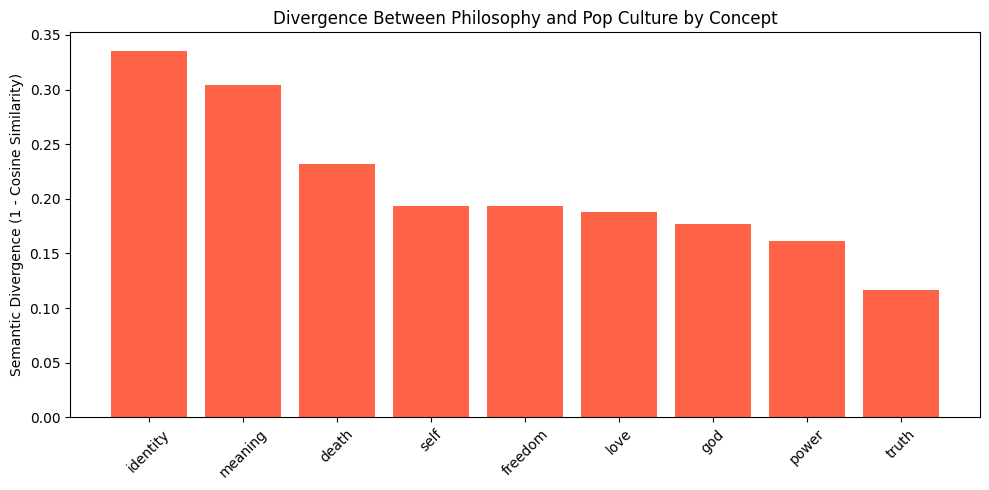

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Load data and embeddings
df = pd.read_csv("C:/Users/USER/Desktop/Projects/philosophy_and_popculture/data/philosophy_vs_popculture_filtered.csv")
embeddings = np.load("C:/Users/USER/Desktop/Projects/philosophy_and_popculture/data/philosophy_vs_popculture_embeddings.npy")

# Attach embeddings to dataframe
embedding_df = pd.DataFrame(embeddings)
df_with_embeddings = pd.concat([df.reset_index(drop=True), embedding_df], axis=1)

# Group by concept and source_type
concepts = df_with_embeddings['concept'].unique()
dim = embeddings.shape[1]
results = []

for concept in concepts:
    group = df_with_embeddings[df_with_embeddings['concept'] == concept]

    if group['source_type'].nunique() < 2:
        continue  # skip if there's no comparison to make

    # Get philosophy and pop culture vectors
    vec_phil = group[group['source_type'] == "philosophy"].iloc[:, -dim:].mean().values
    vec_pop = group[group['source_type'] == "pop_culture"].iloc[:, -dim:].mean().values

    # Compute cosine similarity
    similarity = cosine_similarity([vec_phil], [vec_pop])[0][0]
    divergence = 1 - similarity

    results.append({
        "concept": concept,
        "cosine_similarity": round(similarity, 4),
        "semantic_divergence": round(divergence, 4)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results).sort_values("semantic_divergence", ascending=False)
print(results_df)

# Optional: Save
results_df.to_csv("C:/Users/USER/Desktop/Projects/philosophy_and_popculture/data/embedding_concept_divergence.csv", index=False)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(results_df["concept"], results_df["semantic_divergence"], color='tomato')
plt.ylabel("Semantic Divergence (1 - Cosine Similarity)")
plt.title("Divergence Between Philosophy and Pop Culture by Concept")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
